In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import librosa
import librosa.display

In [6]:
def loader(audio_folder):
    items = sorted(os.listdir(audio_folder))
    specs = []
    name = []
    srs = []
    for item in items:
        path = os.path.join(audio_folder, item)
        if os.path.isdir(path):  # Skip directories
            continue
        try:
            y, sr = librosa.load(path, sr=None)  # Load with original sample rate
            n_mels = 300  # Number of Mel bands
            fmax = 10000  # Maximum frequency
            fmin = 2048
            mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmin=fmin, fmax=fmax)
            mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
            min_val = np.min(mel_spectrogram_db)
            mat = mel_spectrogram_db - min_val
            name.append(os.path.basename(path))
            specs.append(mat)
            srs.append(sr)
        except Exception as e:
            print(f"Error processing {path}: {e}")
    return name, specs, srs



In [8]:
def generate(sig):
    median = np.median(sig)
    newSignal = sig - median
    max_val = np.max(newSignal) / 2
    activation = np.zeros(len(newSignal))
    s = 0
    result = []
    for n, v in enumerate(newSignal):
        if v <= max_val:
            if (n - s) < 2:
                activation[s:n] = 0
            else:
                maxi = np.max(newSignal[s + 1:n])
                if maxi > 0:
                    activation[s + 1:n] = maxi 
                    result.append([maxi, n - (s + 1)])
                else:
                    activation[s + 1:n] = 0.0
            s = n
    return activation, newSignal, max_val, np.array(result)

In [11]:
def process(root_folder):
    genotype_folders = [os.path.join(root_folder, folder) for folder in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, folder))]
    data = []

    for genotype_folder in genotype_folders:
        print(f"Processing genotype folder: {genotype_folder}")
        name, spec, srs = loader(genotype_folder)

        for n, [nome, spe, sr] in enumerate(zip(name, spec, srs)):
            signal = np.median(spe, axis=0)
            activation, newSignal, max_val, result = generate(signal)
            c = 0
            j = 0
            if len(result)>0:
                c = np.sum(result[:, 0])
                j = np.max(result[:, 1])

          #  if j<=9:
                data.append({
                    "Genotype": os.path.basename(genotype_folder),
                    "Sample": os.path.basename(nome),
                    "C Value": c,
                    "J Value": j
                })
    return data

In [13]:
# def process(root_folder):
#     genotype_folders = [os.path.join(root_folder, folder) for folder in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, folder))]
#     data = []

#     for genotype_folder in genotype_folders:
#         print(f"Processing genotype folder: {genotype_folder}")
#         name, spec, srs = loader(genotype_folder)

#         for n, [nome, spe, sr] in enumerate(zip(name, spec, srs)):
#             signal = np.median(spe, axis=0)
#             activation, newSignal, max_val, result = generate(signal)
#             c = 0
#             j = 0
#             if len(result)>0:
#                 c = np.sum(result[:, 0])
#                 j = np.max(result[:, 1])

#           #  if j<=9:
#                 data.append({
#                     "Genotype": os.path.basename(genotype_folder),
#                     "Sample": os.path.basename(nome),
#                     "C Value": c,
#                     "J Value": j
#                 })
#     return data

In [15]:
def plot(data):
    df = pd.DataFrame(data)

    if 'Genotype' not in df.columns:
        print("Error: 'Genotype' column not found in the DataFrame.")
        return

    mean_values_c = df.groupby('Genotype')['C Value'].mean().sort_values()
    sort_c = df.groupby('Genotype')['C Value'].median().sort_values()
    
    sorted_genotypes_c = sort_c.index.tolist()
    sns.set_palette("husl", len(sorted_genotypes_c))
    plt.figure(figsize=(20, 10))
    sns.boxplot(x="Genotype", y="C Value", data=df, order=sorted_genotypes_c)
    sns.stripplot(x="Genotype", y="C Value", data=df, order=sorted_genotypes_c, jitter=True, color='black', size=5, alpha=0.6)

    for i, mean in enumerate(mean_values_c):
        plt.text(i, mean + 0.02, f'{mean:.2f}', ha='center', color='black', weight='bold')
        plt.hlines(mean, i - 0.4, i + 0.4, colors='red', linestyles='--')

    plt.title(f"METHOD 2, BOUNDING BOX USING: {root_folder}")
    plt.xlabel("Genotype")
    plt.ylabel("C Value")
    plt.xticks(rotation=45)
    plt.show()

    mean_values_j = df.groupby('Genotype')['J Value'].mean().sort_values()
    sorted_genotypes_j = mean_values_j.index.tolist()

    sns.set_palette("husl", len(sorted_genotypes_j))
    plt.figure(figsize=(20, 10))
    sns.boxplot(x="Genotype", y="J Value", data=df, order=sorted_genotypes_j)
    sns.stripplot(x="Genotype", y="J Value", data=df, order=sorted_genotypes_j, jitter=True, color='black', size=5, alpha=0.6)

    for i, mean in enumerate(mean_values_j):
        plt.text(i, mean + 0.02, f'{mean:.2f}', ha='center', color='black', weight='bold')
        plt.hlines(mean, i - 0.4, i + 0.4, colors='red', linestyles='--')

    plt.title(f"Juicy using: {root_folder}")
    plt.xlabel("Genotype")
    plt.ylabel("J Value")
    plt.xticks(rotation=45)
    plt.show()

Processing genotype folder: Trimmed_Newdata/FamilyTree_1
Processing genotype folder: Trimmed_Newdata/FamilyTree_2
Processing genotype folder: Trimmed_Newdata/Greenwise_2
Processing genotype folder: Trimmed_Newdata/Driscoll_1
Processing genotype folder: Trimmed_Newdata/Greenwise_1
Processing genotype folder: Trimmed_Newdata/.ipynb_checkpoints
Error processing Trimmed_Newdata/.ipynb_checkpoints/Untitled-checkpoint.ipynb: 
Processing genotype folder: Trimmed_Newdata/Driscoll_2


/tmp/ipykernel_31604/2412915176.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)  # Load with original sample rate
/home/raghav/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


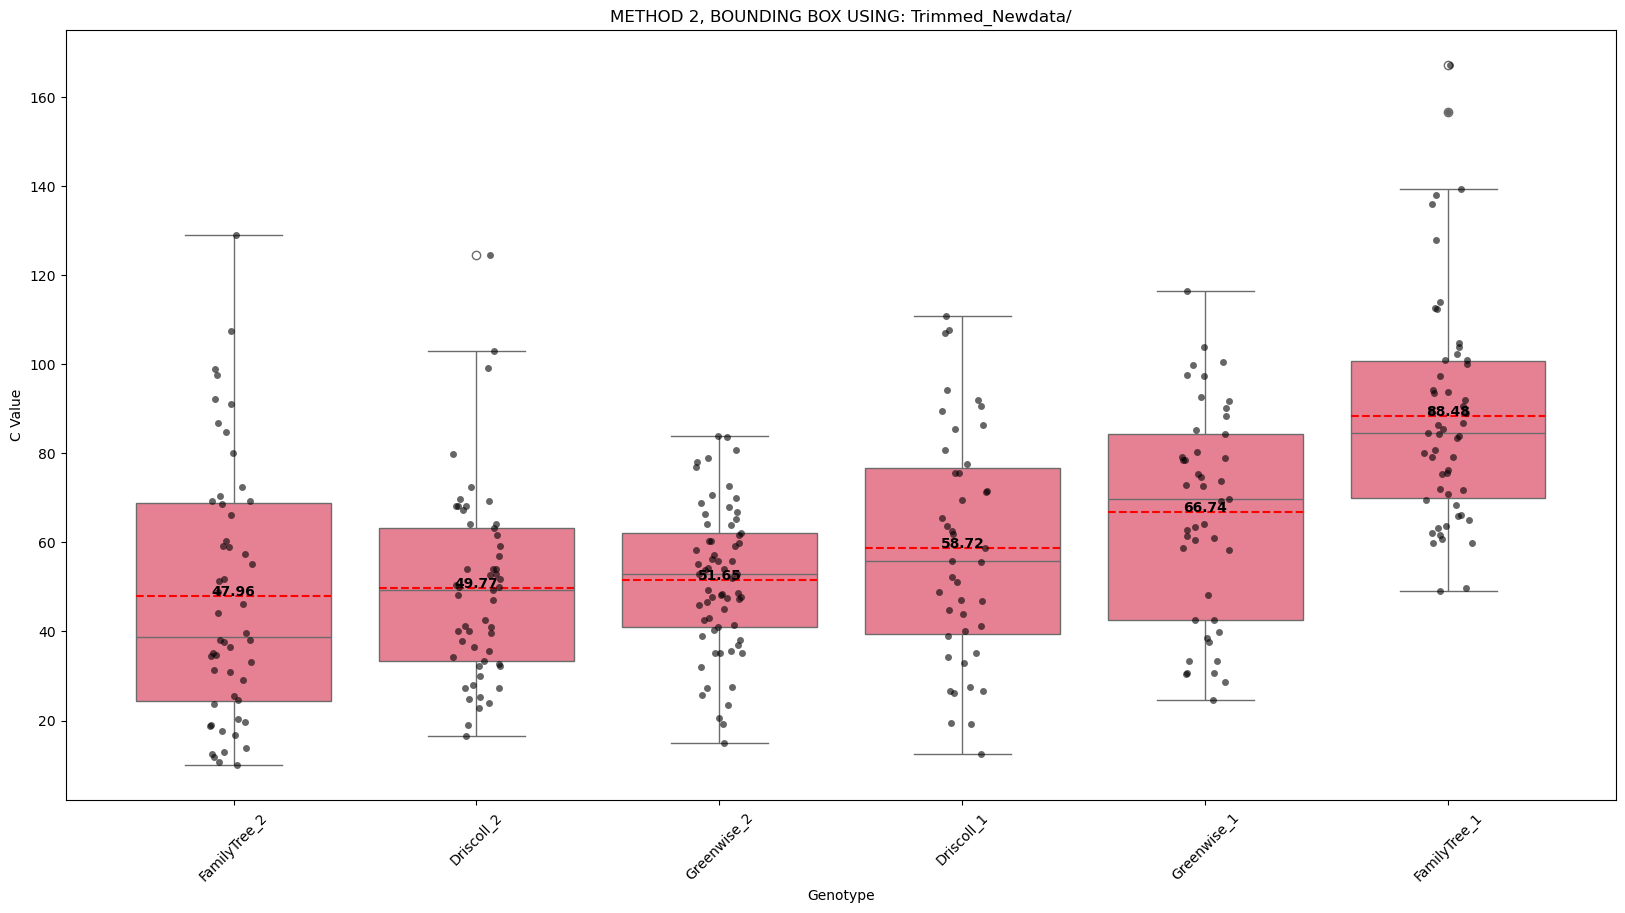

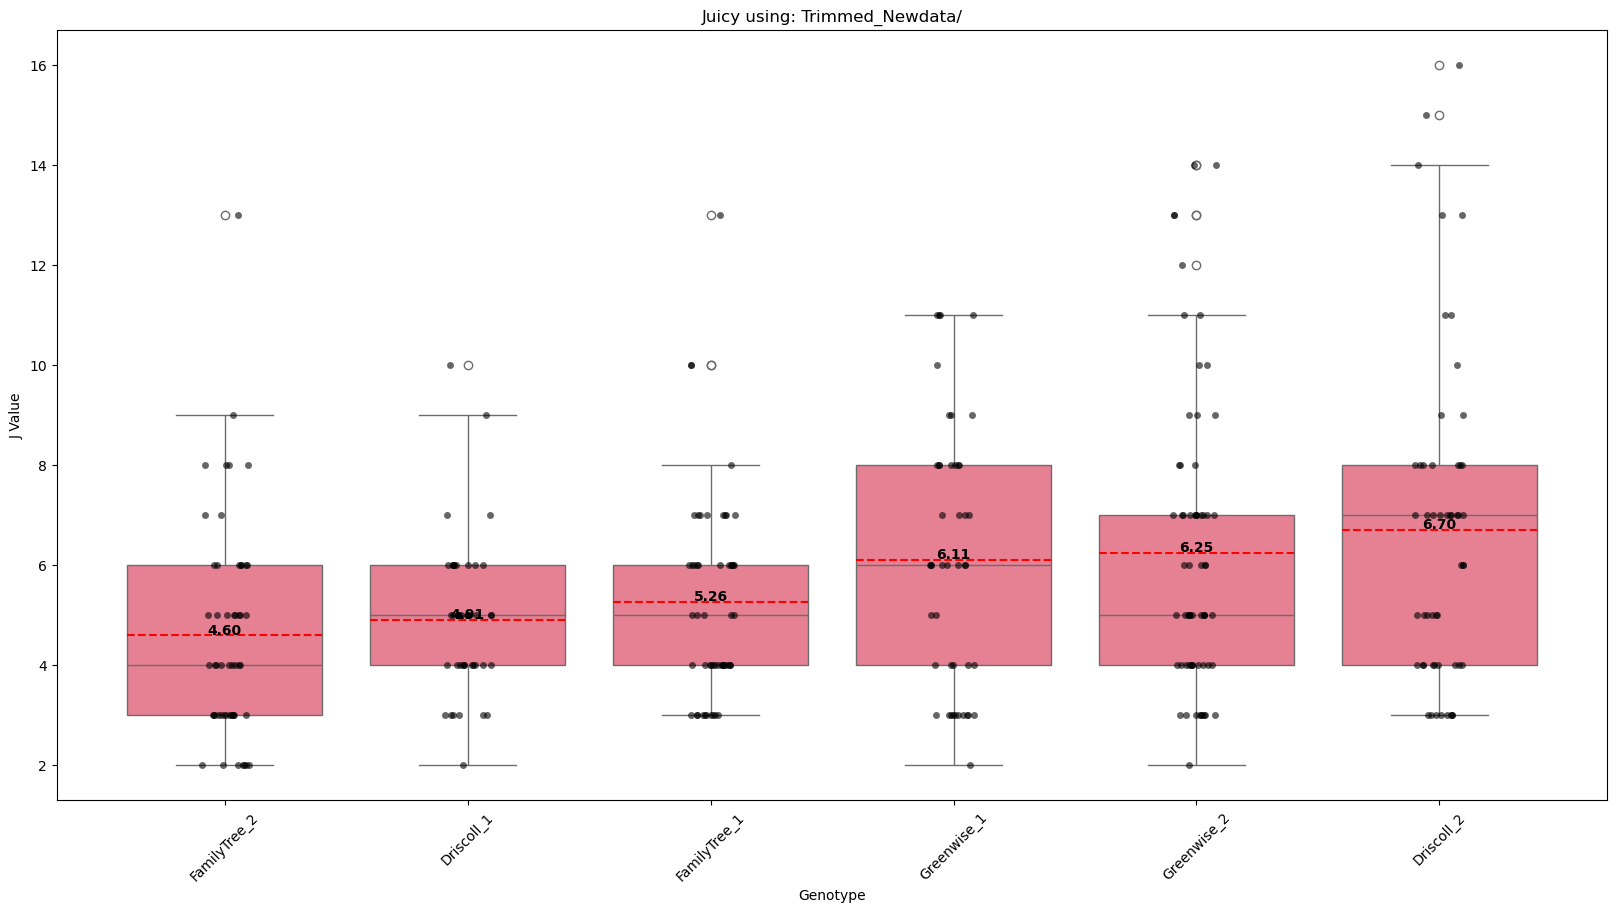

In [35]:
root_folder = 'Trimmed_Newdata/' ## This is the directory path, change accordingly
data = process(root_folder)
plot(data)


